In [48]:
import importlib
import nik_io, nik_train, nik_recon, nik_model
importlib.reload(nik_io)
importlib.reload(nik_train)
importlib.reload(nik_recon)
importlib.reload(nik_model)

import numpy as np
import torch
import matplotlib.pyplot as plt
import glob, os
%matplotlib inline

from nik_io import load_event, load_cartesian_kspace
from nik_train import prepare_tensors, compute_scale
from nik_recon import (
    ifft1d_kz_to_z,
    ifft1d_kz_to_z_cartesian,
    make_fixed_frame_zslice_coil_dataset,
    make_cartesian_eval_dataset,
    nufft2d_recon,
)
from nik_model import WIRE_KXY_REIM

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## Load data

In [49]:
RAD_FILE = '/scratch/rnga/vvpshenov/XCAT-ERIC/results/simulation_results_20260326T114914_rad.mat'
CART_FILE = '/scratch/rnga/vvpshenov/XCAT-ERIC/results/simulation_results_20260326T113845_cart.mat'
t_frame = 0
coil_idx = 0

# Radial
rad = load_event(RAD_FILE, load_images=True, load_coil_maps=True)
k_np = np.transpose(rad['k'], (0, 2, 1, 3))
traj_np = np.transpose(rad['traj'], (0, 2, 1, 3))
T, S, C, RO = k_np.shape
print(f'Radial: T={T}, S={S}, C={C}, RO={RO}')

k_t, traj_t, scales, dims, k_scale = prepare_tensors(k_np, traj_np, data_device=device)
print(f'scales: sx={float(scales[0]):.4f}, sy={float(scales[1]):.4f}, sz={float(scales[2]):.4f}')
print(f'k_scale: {float(k_scale):.2f}')

# Cartesian
cart = load_cartesian_kspace(CART_FILE, load_images=True, load_coil_maps=True)
k_cart_np = cart['k_cart']
print(f'Cartesian k-space: {k_cart_np.shape}')
print(f'Cart meta: {cart["meta"]}')

Radial: T=5, S=2343, C=8, RO=312
scales: sx=0.5000, sy=0.5000, sz=11.0000
k_scale: 55.33
Cartesian k-space: (4, 8, 11, 214, 312)
Cart meta: {'matrixRL': 312, 'matrixAP': 214, 'matrixFH': 11}


## kz → z IFFT

In [50]:
# Radial
k_img_rad, n_z_rad, n_ro_per_slice, kz_sort_order = ifft1d_kz_to_z(k_t, traj_t, t_frame=t_frame)
print(f'Radial after kz->z: {k_img_rad.shape}, n_z={n_z_rad}, n_ro/slice={n_ro_per_slice}')

# Cartesian (uses ifft → fftshift → roll -n//2 to match radial)
k_cart_t = torch.from_numpy(k_cart_np.astype(np.complex64)).to(device)
k_img_cart = ifft1d_kz_to_z_cartesian(k_cart_t)
print(f'Cartesian after kz->z: {k_img_cart.shape}')

Radial after kz->z: torch.Size([5, 213, 8, 11, 312]), n_z=11, n_ro/slice=213
Cartesian after kz->z: torch.Size([4, 8, 11, 214, 312])


## Compare all z-slices: radial NUFFT vs Cartesian IFFT

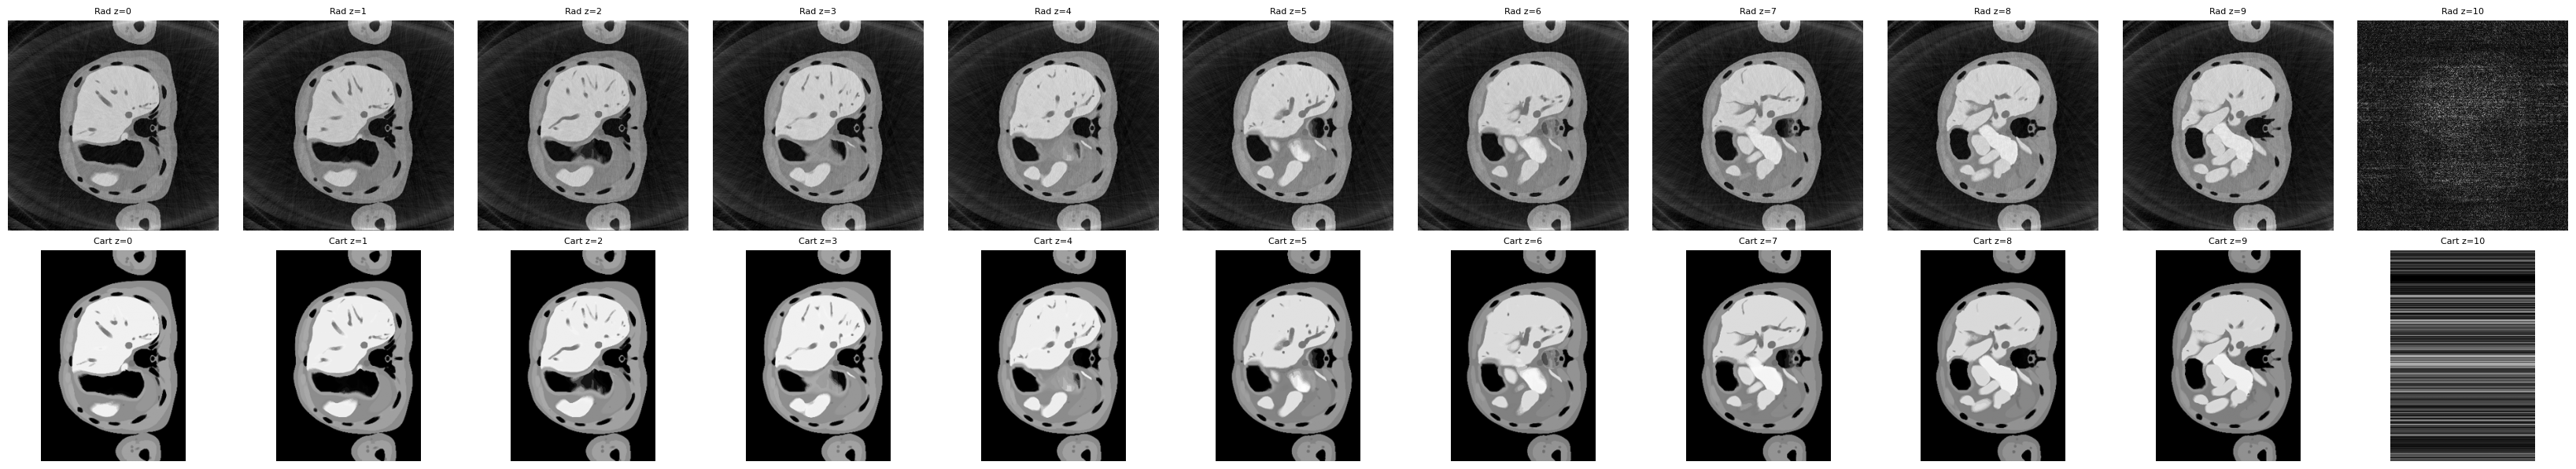

In [51]:
n_z = min(n_z_rad, k_img_cart.shape[2])

fig, axes = plt.subplots(2, n_z, figsize=(3*n_z, 6))
for z in range(n_z):
    # Radial NUFFT
    try:
        img_rad = nufft2d_recon(
            k_img_rad, traj_t, t_frame=t_frame, coil_idx=coil_idx,
            z_slice_idx=z, scales=scales, img_size=(312, 312), n_slices=n_z_rad,
        )
        axes[0, z].imshow(img_rad / (img_rad.max() or 1), cmap='gray')
    except:
        axes[0, z].imshow(np.zeros((312, 312)), cmap='gray')
    axes[0, z].set_title(f'Rad z={z}', fontsize=8)
    axes[0, z].axis('off')

    # Cartesian IFFT (.T to match radial orientation)
    k_sl = k_img_cart[t_frame, coil_idx, z, :, :]
    img_cart = torch.fft.ifft2(k_sl).abs().cpu().numpy().T
    axes[1, z].imshow(img_cart / (img_cart.max() or 1), cmap='gray')
    axes[1, z].set_title(f'Cart z={z}', fontsize=8)
    axes[1, z].axis('off')

axes[0, 0].set_ylabel('Radial', fontsize=12)
axes[1, 0].set_ylabel('Cartesian', fontsize=12)
plt.tight_layout()
plt.show()

## Load trained model

In [52]:
run_dirs = sorted(glob.glob('runs/*carteval'))
print('Available runs:', run_dirs)

run_dir = run_dirs[-1] if run_dirs else None
print(f'Using: {run_dir}')

if run_dir:
    model_path = os.path.join(run_dir, 'model_best.pth')
    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    model = WIRE_KXY_REIM(in_dim=2, hidden=64, depth=8, w0=62.0, s0=10.0).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f'Loaded model from {model_path}')

Available runs: ['runs/20260326_160311_juicy-mutant-wren_carteval', 'runs/20260326_160553_thoughtful-delicate-starfish_carteval', 'runs/20260326_163434_tall-coati-of-joy_carteval', 'runs/20260326_170514_real-petrel-of-bliss_carteval', 'runs/20260326_170838_provocative-vague-bug_carteval', 'runs/20260326_184351_roaring-fantastic-beluga_carteval', 'runs/20260326_185618_wooden-owl-of-action_carteval', 'runs/20260326_190234_acoustic-binturong-from-ganymede_carteval']
Using: runs/20260326_190234_acoustic-binturong-from-ganymede_carteval
Loaded model from runs/20260326_190234_acoustic-binturong-from-ganymede_carteval/model_best.pth


## Radial: model prediction → NUFFT recon

Radial dataset: 66456 points, z_slice=5


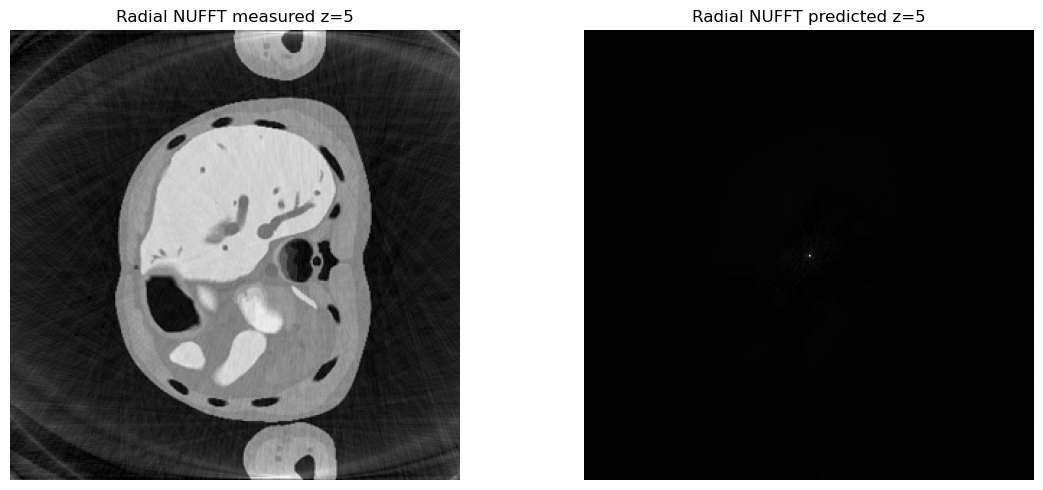

In [53]:
z_slice_idx = n_z_rad // 2

x_all, y_all, kx_all, ky_all, spoke_id_all, ro_id_all, meta_rad = \
    make_fixed_frame_zslice_coil_dataset(
        k_img_rad, traj_t, scales, dims,
        y_scale=k_scale,
        t_fixed=t_frame, coil_fixed=coil_idx,
        z_slice_idx=z_slice_idx, n_slices=n_z_rad,
        compute_device=device,
    )
print(f'Radial dataset: {meta_rad["N"]} points, z_slice={z_slice_idx}')

ys = float(k_scale.item()) if torch.is_tensor(k_scale) else float(k_scale)
with torch.no_grad():
    yp_rad = model(x_all[:, :2].to(device)) * ys
    k_pred_rad = torch.complex(yp_rad[:, 0], yp_rad[:, 1]).reshape(n_ro_per_slice, RO)

k_img_pred = torch.zeros_like(k_img_rad)
k_img_pred[t_frame, :, coil_idx, z_slice_idx, :] = k_pred_rad

img_rad_pred = nufft2d_recon(
    k_img_pred, traj_t, t_frame=t_frame, coil_idx=coil_idx,
    z_slice_idx=z_slice_idx, scales=scales, img_size=(312, 312), n_slices=n_z_rad,
)
img_rad_meas = nufft2d_recon(
    k_img_rad, traj_t, t_frame=t_frame, coil_idx=coil_idx,
    z_slice_idx=z_slice_idx, scales=scales, img_size=(312, 312), n_slices=n_z_rad,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rad_meas / (img_rad_meas.max() or 1), cmap='gray')
axes[0].set_title(f'Radial NUFFT measured z={z_slice_idx}')
axes[1].imshow(img_rad_pred / (img_rad_pred.max() or 1), cmap='gray')
axes[1].set_title(f'Radial NUFFT predicted z={z_slice_idx}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Cartesian: model prediction → IFFT recon

Cartesian eval: 66768 pts, nky=214, nkx=312, z=5


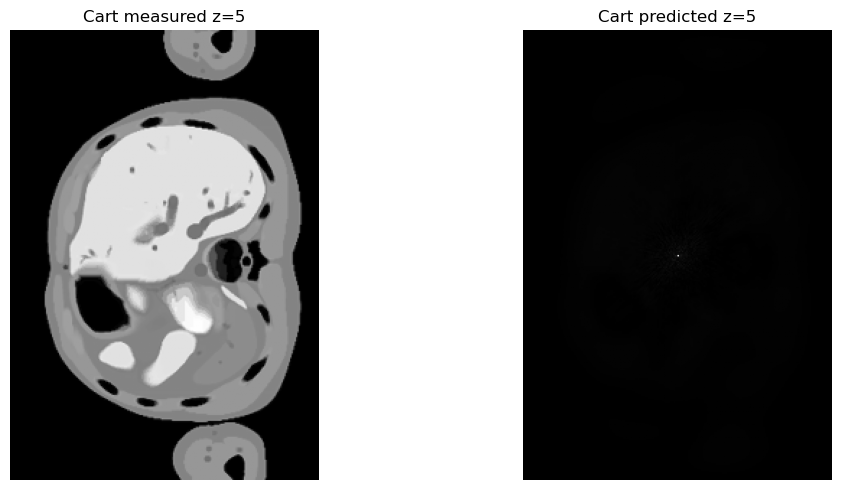

In [54]:
z_cart_idx = k_img_cart.shape[2] // 2

x_cart, y_cart, meta_cart = make_cartesian_eval_dataset(
    k_img_cart,
    t_fixed=min(t_frame, k_img_cart.shape[0]-1),
    coil_fixed=coil_idx,
    z_slice_idx=z_cart_idx,
    scales_radial=scales,
    y_scale=k_scale,
    compute_device=device,
)
nky, nkx = meta_cart['nky'], meta_cart['nkx']
print(f'Cartesian eval: {meta_cart["N"]} pts, nky={nky}, nkx={nkx}, z={z_cart_idx}')

with torch.no_grad():
    yp_cart = model(x_cart.to(device)) * ys
    k_pred_cart = torch.complex(yp_cart[:, 0], yp_cart[:, 1]).reshape(nky, nkx)

k_meas_cart = torch.complex(y_cart[:, 0]*ys, y_cart[:, 1]*ys).reshape(nky, nkx).to(device)

# Measured: ifft2, Predicted: fftshift(ifft2) — different phase conventions
# .T to match radial NUFFT orientation
img_cart_meas = torch.fft.ifft2(k_meas_cart).abs().cpu().numpy().T
img_cart_pred = torch.fft.fftshift(torch.fft.ifft2(k_pred_cart)).abs().cpu().numpy().T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_cart_meas / (img_cart_meas.max() or 1), cmap='gray')
axes[0].set_title(f'Cart measured z={z_cart_idx}')
axes[1].imshow(img_cart_pred / (img_cart_pred.max() or 1), cmap='gray')
axes[1].set_title(f'Cart predicted z={z_cart_idx}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## K-space magnitude comparison

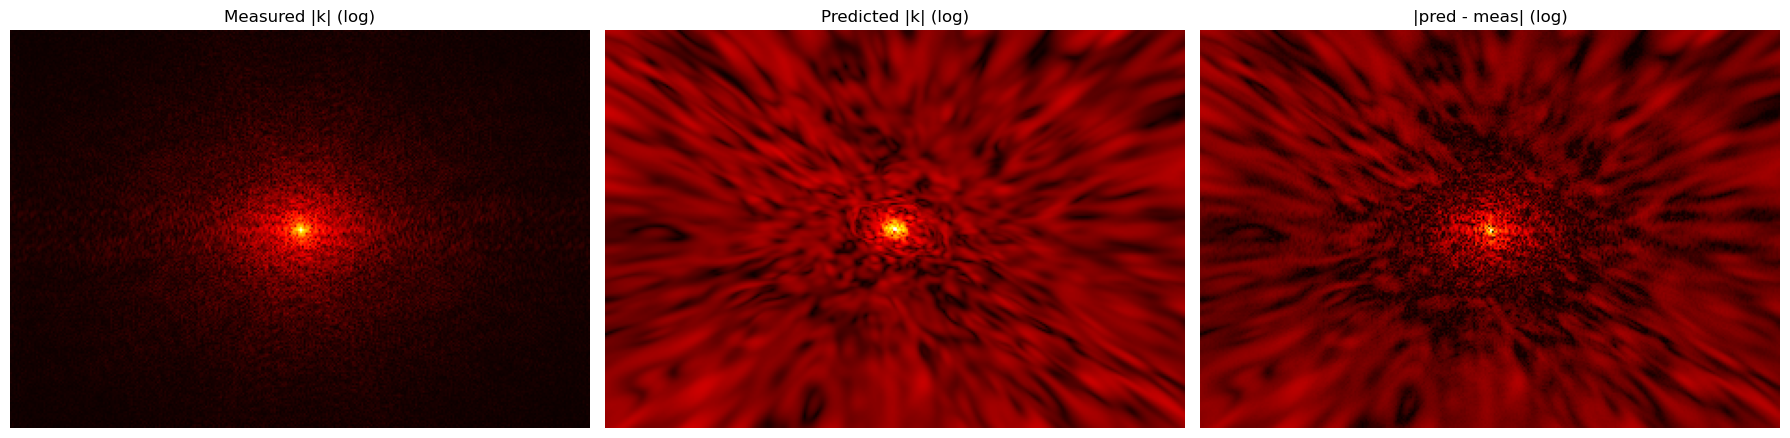

Measured DC at: (np.int64(107), np.int64(156)), Predicted DC at: (np.int64(106), np.int64(155))
Grid center: (107, 156)
Pred k mean: 1.7978, Meas k mean: 0.5848, ratio: 3.07


In [55]:
mag_meas = k_meas_cart.abs().cpu().numpy()
mag_pred = k_pred_cart.abs().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(np.log10(mag_meas + 1), cmap='hot')
axes[0].set_title('Measured |k| (log)')
axes[1].imshow(np.log10(mag_pred + 1), cmap='hot')
axes[1].set_title('Predicted |k| (log)')
axes[2].imshow(np.log10(np.abs(mag_pred - mag_meas) + 1), cmap='hot')
axes[2].set_title('|pred - meas| (log)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

peak_meas = np.unravel_index(mag_meas.argmax(), mag_meas.shape)
peak_pred = np.unravel_index(mag_pred.argmax(), mag_pred.shape)
print(f'Measured DC at: {peak_meas}, Predicted DC at: {peak_pred}')
print(f'Grid center: ({nky//2}, {nkx//2})')
print(f'Pred k mean: {mag_pred.mean():.4f}, Meas k mean: {mag_meas.mean():.4f}, ratio: {mag_pred.mean()/mag_meas.mean():.2f}')

## GT images for reference

GT shape: (61, 11, 312, 214)


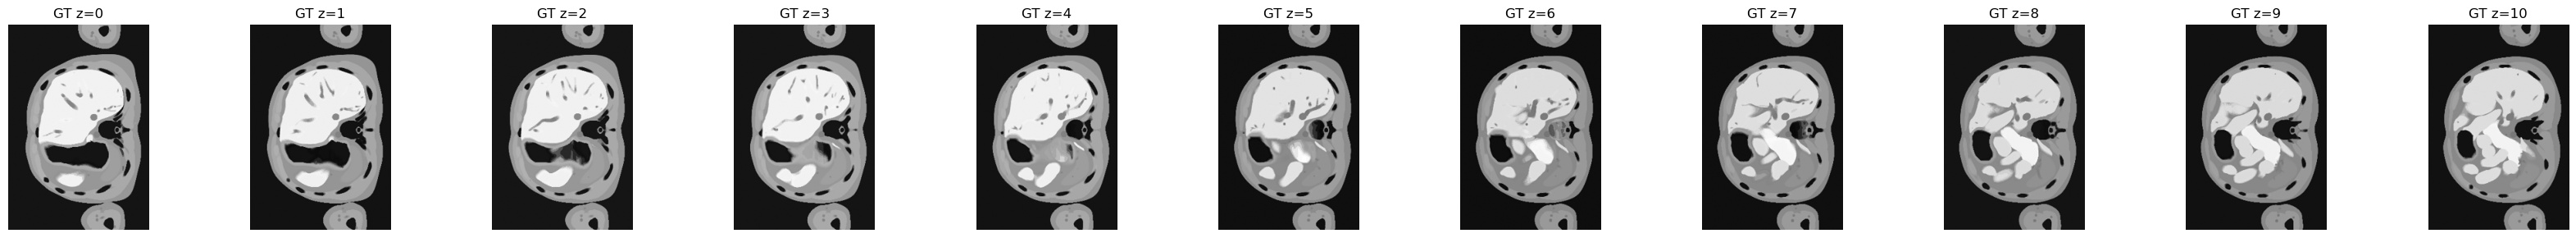

In [56]:
gt_img = cart.get('gt_img')
if gt_img is not None:
    print(f'GT shape: {gt_img.shape}')
    n_z_gt = gt_img.shape[1]
    fig, axes = plt.subplots(1, n_z_gt, figsize=(3*n_z_gt, 3))
    for z in range(n_z_gt):
        sl = gt_img[0, z]
        axes[z].imshow(sl / (sl.max() or 1), cmap='gray')
        axes[z].set_title(f'GT z={z}')
        axes[z].axis('off')
    plt.tight_layout()
    plt.show()